In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [3]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [4]:
print("Sentiment Missing:\n", sentiment.isnull().sum())
print("\nTrades Missing:\n", trades.isnull().sum())

Sentiment Missing:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [5]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [6]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

sentiment['classification'] = sentiment['classification'].replace({
    'Extreme Fear':'Fear',
    'Extreme Greed':'Greed'
})

In [7]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date

In [8]:
data = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')
print(data.shape)

(211224, 18)


In [9]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [10]:
data['win'] = data['Closed PnL'] > 0
win_rate = data.groupby('Account')['win'].mean()

In [11]:
avg_trade_size = data.groupby('Account')['Size USD'].mean()

In [12]:
trades_per_day = data.groupby('date').size()

In [13]:
long_short_ratio = data['Side'].value_counts(normalize=True)
print(long_short_ratio)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [14]:
print(data['Size USD'].describe())

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64


In [15]:
fear_greed_perf = data.groupby('classification')['Closed PnL'].agg(['mean','sum','count'])
print(fear_greed_perf)

                     mean           sum  count
classification                                
Fear            49.212077  4.096266e+06  83237
Greed           53.882281  4.865301e+06  90295
Neutral         34.307718  1.292921e+06  37686


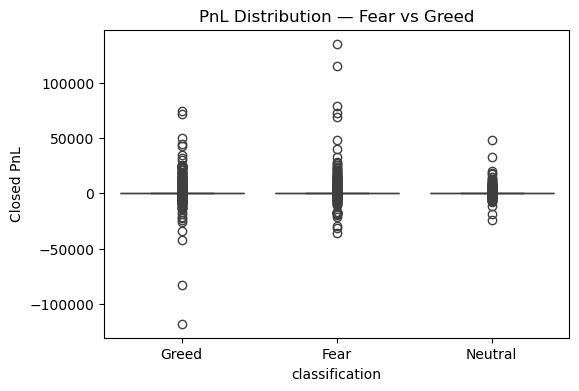

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.title("PnL Distribution — Fear vs Greed")
plt.show()

In [17]:
behavior = data.groupby('classification').agg({
    'Size USD':'mean',
    'Closed PnL':'mean',
    'Account':'count'
}).rename(columns={'Account':'trade_count'})

print(behavior)

                   Size USD  Closed PnL  trade_count
classification                                      
Fear            7182.011019   49.212077        83237
Greed           4574.424490   53.882281        90295
Neutral         4782.732661   34.307718        37686


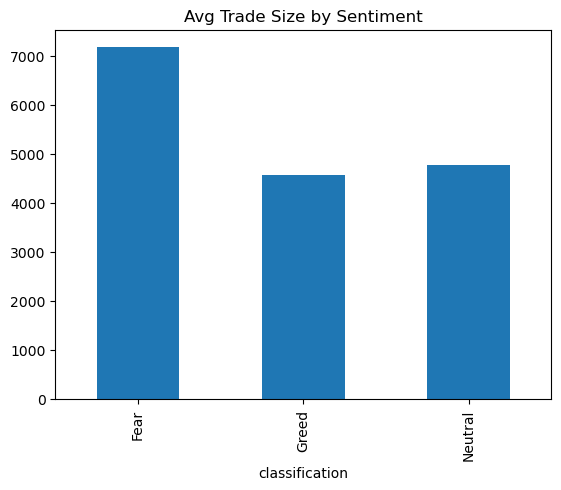

In [18]:
behavior['Size USD'].plot(kind='bar', title="Avg Trade Size by Sentiment")
plt.show()

In [19]:
threshold = data['Size USD'].median()

data['size_segment'] = data['Size USD'].apply(
    lambda x: 'High Size' if x > threshold else 'Low Size'
)

segment_perf = data.groupby(['size_segment','classification'])['Closed PnL'].mean()
print(segment_perf)

size_segment  classification
High Size     Fear               87.647166
              Greed             108.033872
              Neutral            69.581271
Low Size      Fear                2.971356
              Greed               6.387068
              Neutral             2.188668
Name: Closed PnL, dtype: float64


In [20]:
trade_counts = data.groupby('Account').size()
median_trades = trade_counts.median()

freq_map = trade_counts.apply(lambda x: 'Frequent' if x > median_trades else 'Infrequent')
data['freq_segment'] = data['Account'].map(freq_map)

freq_perf = data.groupby(['freq_segment','classification'])['Closed PnL'].mean()
print(freq_perf)

freq_segment  classification
Frequent      Fear               47.325875
              Greed              41.476621
              Neutral            34.579701
Infrequent    Fear               61.968833
              Greed             155.896341
              Neutral            31.845656
Name: Closed PnL, dtype: float64


In [21]:
pnl_std = data.groupby('Account')['Closed PnL'].std()
median_std = pnl_std.median()

consistency_map = pnl_std.apply(lambda x: 'Consistent' if x < median_std else 'Inconsistent')
data['consistency'] = data['Account'].map(consistency_map)

consistency_perf = data.groupby(['consistency','classification'])['Closed PnL'].mean()
print(consistency_perf)

consistency   classification
Consistent    Fear                6.734244
              Greed              27.548685
              Neutral             3.493386
Inconsistent  Fear               90.920235
              Greed             125.211317
              Neutral            83.021460
Name: Closed PnL, dtype: float64


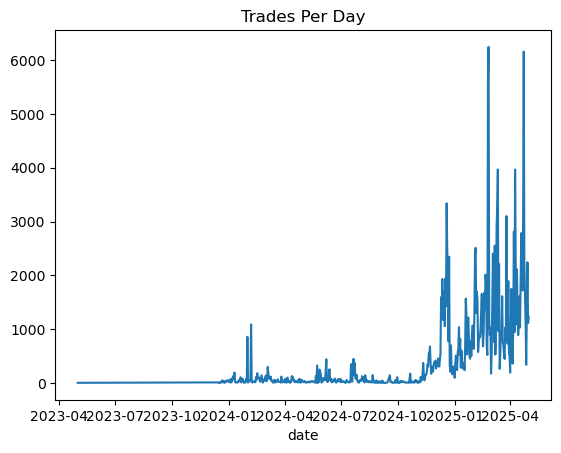

In [22]:
trades_per_day.plot(title="Trades Per Day")
plt.show()

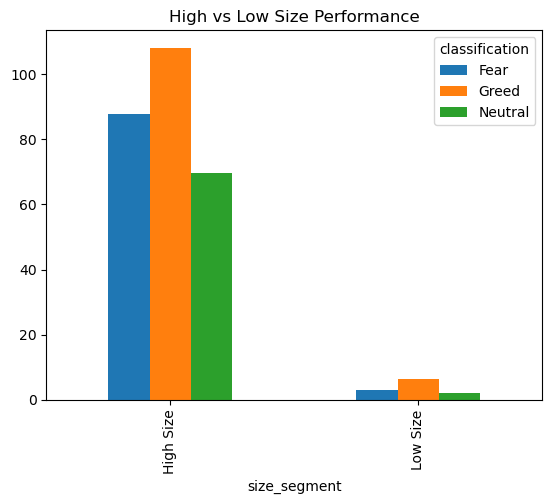

In [23]:
segment_perf.unstack().plot(kind='bar', title="High vs Low Size Performance")
plt.show()

In [24]:
#optional 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data['profit_label'] = (data['Closed PnL'] > 0).astype(int)

X = data[['Size USD']]
y = data['profit_label']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Model Accuracy:", model.score(X_test,y_test))


Model Accuracy: 0.5934903538880341
